# Qwen2.5-0.5B Fine-Tuning with LoRA on Dolly-15k
### Category-wise Cosine Similarity + BLEU/ROUGE Evaluation



In [1]:
# ── Cell 1: Install ───────────────────────────────────────────────────────────
!pip install -q transformers datasets peft accelerate evaluate rouge_score sacrebleu sentence-transformers

import torch, transformers
print("transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.6 MB/s eta 0:00:00
transformers: 5.0.0
CUDA available: True
GPU: Tesla T4
CUDA: 12.8


In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import torch
import numpy as np
from collections import defaultdict, Counter
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model
import evaluate

In [3]:
# ── Cell 3: Config ────────────────────────────────────────────────────────────
MODEL_NAME   = "Qwen/Qwen2.5-0.5B"
OUTPUT_DIR   = "/kaggle/working/qwen-lora"
BATCH_SIZE   = 4
EPOCHS       = 10
MAX_LENGTH   = 512
EVAL_SAMPLES = 100   # samples used for BLEU/ROUGE/cosine eval after training

In [4]:
# ── Cell 4: Load & Split Dataset ─────────────────────────────────────────────
dataset = load_dataset("databricks/databricks-dolly-15k")

# Show category distribution
cats = Counter(dataset['train']['category'])
print("Category distribution:")
for k, v in sorted(cats.items()):
    print(f"  {k:<30} {v}")

# Train / Val / Test split
train_dataset = dataset['train'].select(range(8000))
val_dataset   = dataset['train'].select(range(8000, 10000))
test_dataset  = dataset['train'].select(range(10000, 12000))
print(f"\nSizes — train:{len(train_dataset)}, val:{len(val_dataset)}, test:{len(test_dataset)}")

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Category distribution:
  brainstorming                  1766
  classification                 2136
  closed_qa                      1773
  creative_writing               709
  general_qa                     2191
  information_extraction         1506
  open_qa                        3742
  summarization                  1188

Sizes — train:8000, val:2000, test:2000


In [5]:
# ── Cell 5: Tokenizer & Preprocessing ────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

def format_example(example):
    prompt = f"Instruction: {example['instruction']}\nResponse:"
    return {"text": prompt + " " + example['response']}

train_dataset = train_dataset.map(format_example)
val_dataset   = val_dataset.map(format_example)
test_dataset  = test_dataset.map(format_example)

def tokenize(example):
        tokens = tokenizer(
        example['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )
    tokens['labels'] = tokens['input_ids'].copy()
    return tokens

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)
print("Tokenisation done.")

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenisation done.


In [6]:
# ── Cell 6: Load Model ────────────────────────────────────────────────────────

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.float16   
)
print("Model loaded.")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Model loaded.


In [7]:
# ── Cell 7: LoRA Config ───────────────────────────────────────────────────────
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


In [8]:
# ── Cell 8: Training Arguments ────────────────────────────────────────────────

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    eval_strategy="epoch",          
    save_strategy="epoch",

    num_train_epochs=EPOCHS,
    learning_rate=2e-4,

    logging_steps=50,
    warmup_ratio=0.03,
    max_grad_norm=0.3,

    load_best_model_at_end=True,
    fp16=True,
    fp16_full_eval=False,           
    report_to="none"
)
print("TrainingArguments ready.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TrainingArguments ready.


In [9]:
# ── Cell 9: Trainer ───────────────────────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)
print("Trainer ready.")

Trainer ready.


In [10]:
# ── Cell 10: Response generator ───────────────────────────────────────────────
def generate_response(prompt, max_new_tokens=150):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

sample_prompt = "Instruction: Explain Machine Learning\nResponse:"
print("Before Fine-tuning:\n", generate_response(sample_prompt))

Before Fine-tuning:
 Instruction: Explain Machine Learning
Response: Machine learning is a subset of artificial intelligence that involves the development of algorithms that can learn from data and improve their performance over time. It is a field of study that focuses on the development of models that can make predictions or decisions based on data, without being explicitly programmed to do so. Machine learning algorithms are designed to identify patterns and relationships in data, and then use this information to make predictions or decisions. This can be done using a variety of techniques, including supervised learning, unsupervised learning, and reinforcement learning. Machine learning is used in a wide range of applications, from image and speech recognition to natural language processing and predictive analytics.


In [11]:
# ── Cell 11: TRAIN ────────────────────────────────────────────────────────────
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.395124,0.428200
2,0.399721,0.426660
3,0.435614,0.426853
4,0.370703,0.427577
5,0.440551,0.428846
6,0.369457,0.430003
7,0.403699,0.430862
8,0.388477,0.432049
9,0.371343,0.432733
10,0.394058,0.433209


TrainOutput(global_step=10000, training_loss=0.5098826719284058, metrics={'train_runtime': 8009.7555, 'train_samples_per_second': 9.988, 'train_steps_per_second': 1.248, 'total_flos': 8.808991555584e+16, 'train_loss': 0.5098826719284058, 'epoch': 10.0})

In [12]:
# ── Cell 12: After Fine-Tuning Inference ──────────────────────────────────────
print("\nAfter Fine-tuning:\n", generate_response(sample_prompt))


After Fine-tuning:
 Instruction: Explain Machine Learning
Response: Machine learning is a subset of artificial intelligence that involves the development of algorithms that can learn from data and improve their performance over time. It is a subset of artificial intelligence that involves the development of algorithms that can learn from data and improve their performance over time. Machine learning algorithms are designed to make predictions or decisions based on patterns and relationships in data, rather than being explicitly programmed to perform a specific task. Machine learning algorithms can be used for a wide range of applications, including image and speech recognition, natural language processing, and predictive analytics.


In [13]:
# ── Cell 13: Eval Loss — SAFE (fresh Trainer avoids RuntimeError) ─────────────

from transformers import Trainer as _Trainer, TrainingArguments as _TA

eval_only_args = _TA(
    output_dir=OUTPUT_DIR,
    per_device_eval_batch_size=BATCH_SIZE,
    fp16=False,            # fp32 eval is stable
    report_to="none"
)
eval_trainer = _Trainer(
    model=model,
    args=eval_only_args,
    eval_dataset=val_dataset
)
eval_results = eval_trainer.evaluate()
print("\nFinal Eval Loss:", round(eval_results['eval_loss'], 4))


Final Eval Loss: 0.4267


In [14]:
# ── Cell 14: Generate test predictions (with category labels) ─────────────────
predictions = []
references  = []
categories  = []

test_subset = test_dataset.select(range(EVAL_SAMPLES))

model.eval()
for example in test_subset:
    decoded_input = tokenizer.decode(example['input_ids'], skip_special_tokens=True)
    inputs = tokenizer(
        decoded_input,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=80,
            pad_token_id=tokenizer.pad_token_id
        )

    pred = tokenizer.decode(output[0], skip_special_tokens=True)
    ref  = tokenizer.decode(example['labels'], skip_special_tokens=True)
    cat  = example['category']

    predictions.append(pred)
    references.append([ref])
    categories.append(cat)

print(f"Generated {len(predictions)} predictions.")
print("Category breakdown:", Counter(categories))

Generated 100 predictions.
Category breakdown: Counter({'general_qa': 21, 'open_qa': 20, 'brainstorming': 14, 'classification': 12, 'closed_qa': 11, 'information_extraction': 10, 'summarization': 9, 'creative_writing': 3})


In [15]:
# ── Cell 15: Show 5 examples ──────────────────────────────────────────────────
for i in range(min(5, len(predictions))):
    print(f"\nExample {i+1}  [category: {categories[i]}]")
    print("-" * 60)
    print("Prediction:\n", predictions[i])
    print("\nReference:\n",  references[i][0])


Example 1  [category: open_qa]
------------------------------------------------------------
Prediction:
 Instruction: what is the number of US house of representatives?
Response: 435

Reference:
 Instruction: what is the number of US house of representatives?
Response: 435

Example 2  [category: closed_qa]
------------------------------------------------------------
Prediction:
 Instruction: What is hidden at Oak Island?
Response: Oak Island is rumored to have Captain Kidd's treasure buried. However despite numerous excavation attempts over the past 100 years nothing has been discovered. There are other theories which claim religious artifacts, manuscripts, or Marie Antionette's jewels are hidden at Oak Island.

Reference:
 Instruction: What is hidden at Oak Island?
Response: Oak Island is rumored to have Captain Kidd's treasure buried. However despite numerous excavation attempts over the past 100 years nothing has been discovered. There are other theories which claim religious artif

In [16]:
# ── Cell 16: BLEU & ROUGE (overall) ──────────────────────────────────────────
bleu  = evaluate.load("bleu")
rouge = evaluate.load("rouge")

bleu_score  = bleu.compute(predictions=predictions, references=references)
rouge_score = rouge.compute(
    predictions=predictions,
    references=[r[0] for r in references]
)

print("BLEU Score: ", bleu_score)
print("ROUGE Score:", rouge_score)

BLEU Score:  {'bleu': 0.9019412264064717, 'precisions': [0.9034371535127508, 0.9024539252621933, 0.9014504680588417, 0.9004261511277414], 'brevity_penalty': 1.0, 'length_ratio': 1.1068838558518352, 'translation_length': 9921, 'reference_length': 8963}
ROUGE Score: {'rouge1': np.float64(0.9496650222928434), 'rouge2': np.float64(0.9490348345642321), 'rougeL': np.float64(0.9491758272337205), 'rougeLsum': np.float64(0.9501850451063407)}


In [17]:
# ── Cell 17: Category-wise Cosine Similarity ──────────────────────────────────
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

print("Loading sentence encoder...")
sim_model = SentenceTransformer("all-MiniLM-L6-v2")

# Group by category
cat_preds = defaultdict(list)
cat_refs  = defaultdict(list)
for pred, ref_list, cat in zip(predictions, references, categories):
    cat_preds[cat].append(pred)
    cat_refs[cat].append(ref_list[0])

# Per-category cosine similarity
cat_cosine = {}
print(f"\n{'Category':<30} {'N':>4}  {'CosSim':>8}")
print("-" * 46)
for cat in sorted(cat_preds.keys()):
    p_emb = sim_model.encode(cat_preds[cat], convert_to_numpy=True, show_progress_bar=False)
    r_emb = sim_model.encode(cat_refs[cat],  convert_to_numpy=True, show_progress_bar=False)
    sims  = [sk_cosine([p], [r])[0][0] for p, r in zip(p_emb, r_emb)]
    cat_cosine[cat] = float(np.mean(sims))
    print(f"{cat:<30} {len(cat_preds[cat]):>4}  {cat_cosine[cat]:>8.4f}")

overall_cosine = float(np.mean(list(cat_cosine.values())))
print(f"\n{'OVERALL':<30}       {overall_cosine:>8.4f}")

Loading sentence encoder...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Category                          N    CosSim
----------------------------------------------
brainstorming                    14    0.9970
classification                   12    0.9768
closed_qa                        11    0.9964
creative_writing                  3    1.0000
general_qa                       21    0.9973
information_extraction           10    0.9805
open_qa                          20    0.9865
summarization                     9    0.9920

OVERALL                                0.9908


In [18]:
# ── Cell 18: Per-category ROUGE-L + Cosine table ─────────────────────────────
print(f"\n{'Category':<30} {'N':>4} {'CosSim':>8} {'ROUGE-L':>8}")
print("-" * 55)
for cat in sorted(cat_preds.keys()):
    cat_rouge = rouge.compute(
        predictions=cat_preds[cat],
        references=cat_refs[cat]
    )
    print(f"{cat:<30} {len(cat_preds[cat]):>4} "
          f"{cat_cosine[cat]:>8.4f} "
          f"{float(cat_rouge['rougeL']):>8.4f}")


Category                          N   CosSim  ROUGE-L
-------------------------------------------------------
brainstorming                    14   0.9970   0.9878
classification                   12   0.9768   0.9091
closed_qa                        11   0.9964   0.9812
creative_writing                  3   1.0000   0.9745
general_qa                       21   0.9973   0.9818
information_extraction           10   0.9805   0.9340
open_qa                          20   0.9865   0.9041
summarization                     9   0.9920   0.9522


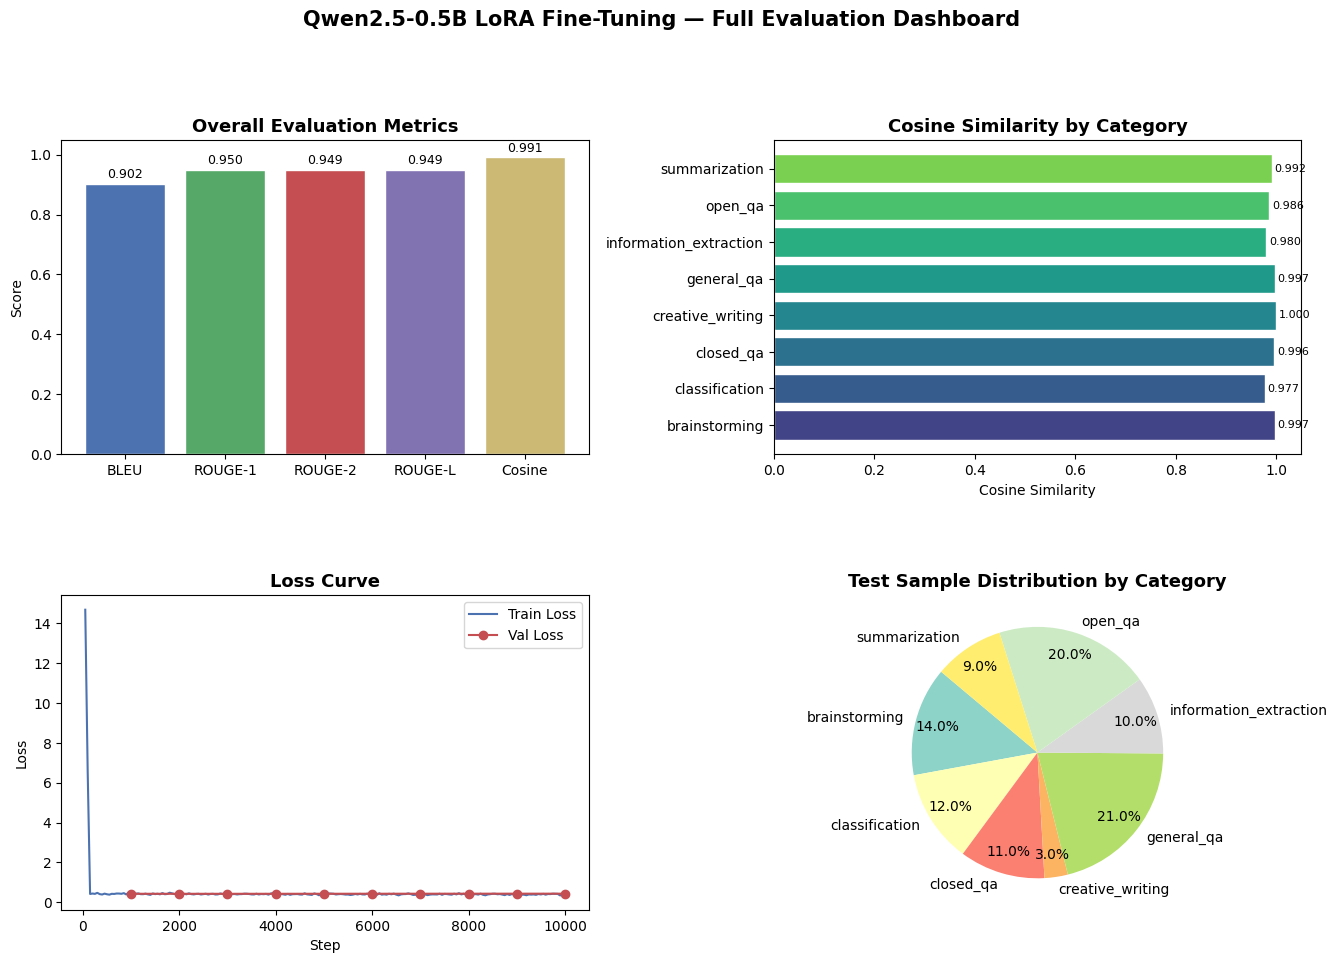

Saved → /kaggle/working/evaluation_dashboard.png


In [19]:
# ── Cell 19: Evaluation Dashboard (4-panel plot) ─────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1 — Overall metrics
ax1 = fig.add_subplot(gs[0, 0])
metrics = {
    "BLEU":    bleu_score["bleu"],
    "ROUGE-1": float(rouge_score["rouge1"]),
    "ROUGE-2": float(rouge_score["rouge2"]),
    "ROUGE-L": float(rouge_score["rougeL"]),
    "Cosine":  overall_cosine
}
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
ax1.bar(metrics.keys(), metrics.values(), color=colors, edgecolor='white')
ax1.set_title("Overall Evaluation Metrics", fontsize=13, fontweight='bold')
ax1.set_ylabel("Score"); ax1.set_ylim(0, 1.05)
for i, (k, v) in enumerate(metrics.items()):
    ax1.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9)

# Panel 2 — Category cosine similarity
ax2 = fig.add_subplot(gs[0, 1])
cats_sorted = sorted(cat_cosine.keys())
cvals = [cat_cosine[c] for c in cats_sorted]
bars  = ax2.barh(cats_sorted, cvals,
                 color=plt.cm.viridis(np.linspace(0.2, 0.8, len(cats_sorted))),
                 edgecolor='white')
ax2.set_title("Cosine Similarity by Category", fontsize=13, fontweight='bold')
ax2.set_xlabel("Cosine Similarity"); ax2.set_xlim(0, 1.05)
for bar, val in zip(bars, cvals):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va='center', fontsize=8)

# Panel 3 — Training & Validation Loss
ax3 = fig.add_subplot(gs[1, 0])
logs = trainer.state.log_history
train_steps  = [e['step'] for e in logs if 'loss' in e and 'eval_loss' not in e]
train_losses = [e['loss'] for e in logs if 'loss' in e and 'eval_loss' not in e]
val_steps    = [e['step'] for e in logs if 'eval_loss' in e]
val_losses   = [e['eval_loss'] for e in logs if 'eval_loss' in e]
if train_steps:  ax3.plot(train_steps, train_losses, label='Train Loss', color='#4C72B0')
if val_steps:    ax3.plot(val_steps, val_losses, 'o-', label='Val Loss', color='#C44E52')
ax3.set_title("Loss Curve", fontsize=13, fontweight='bold')
ax3.set_xlabel("Step"); ax3.set_ylabel("Loss"); ax3.legend()

# Panel 4 — Category pie
ax4 = fig.add_subplot(gs[1, 1])
cat_n = [len(cat_preds[c]) for c in cats_sorted]
ax4.pie(cat_n, labels=cats_sorted, autopct='%1.1f%%',
        colors=plt.cm.Set3(np.linspace(0, 1, len(cats_sorted))),
        startangle=140, pctdistance=0.82)
ax4.set_title("Test Sample Distribution by Category", fontsize=13, fontweight='bold')

fig.suptitle("Qwen2.5-0.5B LoRA Fine-Tuning — Full Evaluation Dashboard",
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig("/kaggle/working/evaluation_dashboard.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved → /kaggle/working/evaluation_dashboard.png")

In [20]:
# ── Cell 20: Save Model & Tokenizer ──────────────────────────────────────────
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Model and tokenizer saved to", OUTPUT_DIR)

Model and tokenizer saved to /kaggle/working/qwen-lora
